# Customer Churn EDA

This notebook performs Step 6 exploratory data analysis on `data/processed/model_dataset.csv`, using the validated Step 5 dataset. The goal is to answer business questions, identify high-risk customer segments, and create clean figures for manager or mentor review.

Scope:

- Descriptive EDA only.
- No hypothesis testing.
- No modeling.
- No causal claims.
- `customer_id` is retained only for traceability and is not treated as an analytical feature.

Business questions:

1. What is the overall churn rate?
2. Which contract types have the highest churn?
3. Which tenure groups have the highest churn?
4. How do `monthly_charges` differ between churned and non-churned customers?
5. Which service-related features are most associated with churn?
6. Which payment methods are highest risk?


## Setup

Load the validated modeling dataset and define lightweight plotting helpers. Paths are resolved from either the project root or the `notebooks/` directory so the notebook is easy to run locally.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "model_dataset.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "model_dataset.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

BASE_COLOR = "#4C78A8"
RISK_COLOR = "#E45756"
SUPPORT_COLOR = "#54A24B"
NEUTRAL_COLOR = "#BAB0AC"
CHURN_COLORS = {"No": BASE_COLOR, "Yes": RISK_COLOR}


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


def churn_rate_table(data, column, order=None, sort_by_rate=False):
    summary = (
        data.groupby(column, dropna=False)
        .agg(
            customers=("customer_id", "count"),
            churned=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean"),
        )
        .reset_index()
    )
    if order is not None:
        summary[column] = pd.Categorical(summary[column], categories=order, ordered=True)
        summary = summary.sort_values(column)
        summary[column] = summary[column].astype(str)
    if sort_by_rate:
        summary = summary.sort_values("churn_rate", ascending=False)
    summary["churn_rate_pct"] = summary["churn_rate"] * 100
    return summary.reset_index(drop=True)


def add_vertical_labels(ax, values, pct=True):
    for patch, value in zip(ax.patches, values):
        label = f"{value:.1%}" if pct else f"{value:,.0f}"
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=9,
        )


def add_horizontal_labels(ax, values):
    for patch, value in zip(ax.patches, values):
        ax.annotate(
            f"{value:.1%}",
            (patch.get_width(), patch.get_y() + patch.get_height() / 2),
            ha="left",
            va="center",
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=9,
        )

## Load And Validate Shape

Before plotting, confirm the dataset dimensions, key columns, and target values. This is not a full validation step because Step 5 already covered that; this is a quick EDA sanity check.

In [2]:
df = pd.read_csv(DATA_PATH)
df["churn_flag"] = df["churn"].eq("Yes").astype(int)

print(f"Dataset path: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate customer_id rows: {df['customer_id'].duplicated().sum():,}")
print(f"Missing values: {df.isna().sum().sum():,}")

schema_preview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "n_unique": df.nunique(dropna=False).values,
})
display(schema_preview)

display(df.head())

Dataset path: data\processed\model_dataset.csv
Rows: 7,032
Columns: 35
Duplicate customer_id rows: 0
Missing values: 0


,column,dtype,missing,n_unique
0,customer_id,object,0,7032
1,gender,object,0,2
2,senior_citizen,int64,0,2
3,partner,object,0,2
4,dependents,object,0,2
5,tenure,int64,0,72
6,contract,object,0,3
7,paperless_billing,object,0,2
8,churn,object,0,2
9,phone_service,object,0,2


,customer_id,gender,senior_citizen,partner,dependents,tenure,contract,paperless_billing,churn,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,payment_method,monthly_charges,total_charges,tenure_group,is_new_customer,is_month_to_month,is_paperless_billing,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,monthly_charge_band,is_electronic_check,is_total_charges_missing,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,Month-to-month,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Electronic check,29.850,29.850,0-11 months,1,1,1,0,1,0,0,0,0,Low,1,0,0
1,5575-GNVDE,Male,0,No,No,34,One year,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,Mailed check,56.950,1889.500,24-47 months,0,0,0,1,0,1,0,0,0,Medium,0,0,0
2,3668-QPYBK,Male,0,No,No,2,Month-to-month,Yes,Yes,Yes,No,DSL,Yes,Yes,No,No,No,No,Mailed check,53.850,108.150,0-11 months,1,1,1,1,1,0,0,0,0,Medium,0,0,1
3,7795-CFOCW,Male,0,No,No,45,One year,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,Bank transfer (automatic),42.300,1840.750,24-47 months,0,0,0,1,0,1,1,0,0,Medium,0,0,0
4,9237-HQITU,Female,0,No,No,2,Month-to-month,Yes,Yes,Yes,No,Fiber optic,No,No,No,No,No,No,Electronic check,70.700,151.650,0-11 months,1,1,1,0,0,0,0,0,0,High,1,0,1


## Overall Churn Distribution

Question answered: What is the overall churn rate?

This establishes the baseline risk level for the customer base. Later segment-level churn rates should be interpreted relative to this baseline.

,churn,customers,customer_share
0,No,5163,0.734
1,Yes,1869,0.266


Saved: reports\figures\churn_distribution.png


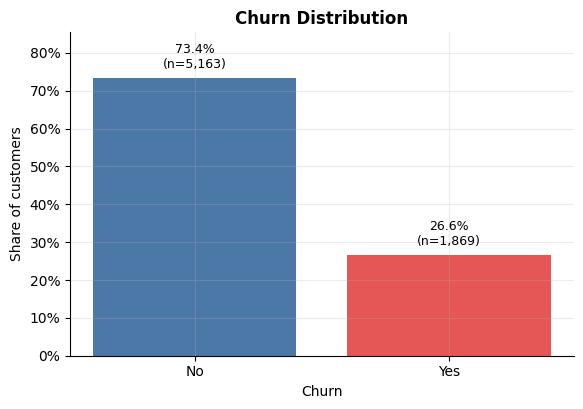

In [3]:
churn_summary = (
    df["churn"]
    .value_counts()
    .rename_axis("churn")
    .reset_index(name="customers")
)
churn_summary["customer_share"] = churn_summary["customers"] / len(df)
churn_summary = churn_summary.sort_values("churn")

display(churn_summary)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(
    churn_summary["churn"],
    churn_summary["customer_share"],
    color=[CHURN_COLORS.get(value, BASE_COLOR) for value in churn_summary["churn"]],
)
ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Share of customers")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(churn_summary["customer_share"]) + 0.12)

for patch, (_, row) in zip(bars, churn_summary.iterrows()):
    ax.annotate(
        f"{row['customer_share']:.1%}\n(n={int(row['customers']):,})",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=9,
    )

path = save_figure(fig, "churn_distribution.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()

**Conclusion:** Overall churn is **26.6%** (1,869 of 7,032 customers). This is the benchmark for prioritizing high-risk segments.

## Churn By Contract Type

Question answered: Which contract types have the highest churn?

Contract type is a business-actionable segmentation variable because it reflects customer commitment level and potential retention levers such as renewal incentives, plan migration, or targeted offers.

,contract,customers,churned,churn_rate,churn_rate_pct
0,Month-to-month,3875,1655,0.427,42.710
1,One year,1472,166,0.113,11.277
2,Two year,1685,48,0.028,2.849


Saved: reports\figures\churn_rate_by_contract.png


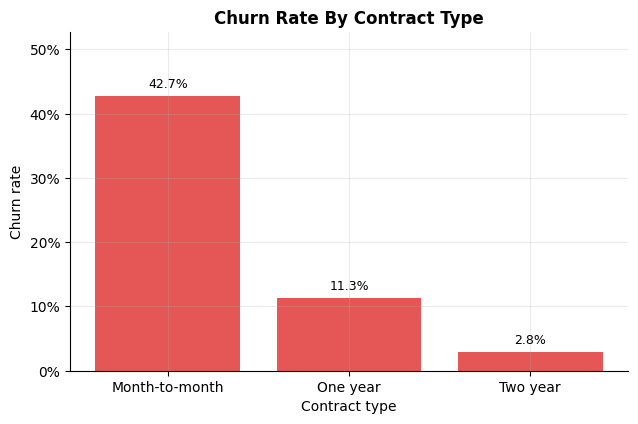

In [4]:
contract_summary = churn_rate_table(df, "contract", sort_by_rate=True)
display(contract_summary)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
bars = ax.bar(contract_summary["contract"], contract_summary["churn_rate"], color=RISK_COLOR)
ax.set_title("Churn Rate By Contract Type")
ax.set_xlabel("Contract type")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(contract_summary["churn_rate"]) + 0.10)
add_vertical_labels(ax, contract_summary["churn_rate"])

path = save_figure(fig, "churn_rate_by_contract.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()

**Conclusion:** Month-to-month customers have the highest churn at **42.7%**. This segment includes **3,875 customers** and **1,655 churned customers**, so it is both high-risk and large. One-year contracts churn at **11.3%** and two-year contracts churn at **2.8%**.


## Churn By Tenure Group

Question answered: Which tenure groups have the highest churn?

Tenure groups show where churn risk concentrates across the customer lifecycle. This is especially useful for retention timing, onboarding design, and cohort monitoring.

,tenure_group,customers,churned,churn_rate,churn_rate_pct
0,0-11 months,2058,999,0.485,48.542
1,12-23 months,1047,309,0.295,29.513
2,24-47 months,1624,339,0.209,20.874
3,48+ months,2303,222,0.096,9.640


Saved: reports\figures\churn_rate_by_tenure_group.png


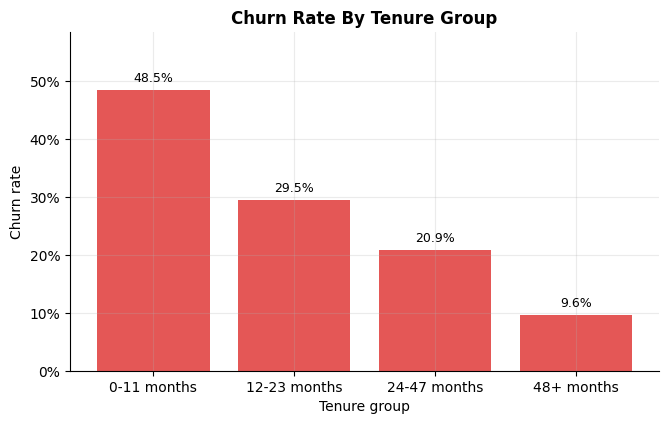

In [5]:
tenure_order = ["0-11 months", "12-23 months", "24-47 months", "48+ months"]
tenure_summary = churn_rate_table(df, "tenure_group", order=tenure_order)
display(tenure_summary)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
bars = ax.bar(tenure_summary["tenure_group"], tenure_summary["churn_rate"], color=RISK_COLOR)
ax.set_title("Churn Rate By Tenure Group")
ax.set_xlabel("Tenure group")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(tenure_summary["churn_rate"]) + 0.10)
add_vertical_labels(ax, tenure_summary["churn_rate"])

path = save_figure(fig, "churn_rate_by_tenure_group.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()

**Conclusion:** Customers in the `0-11 months` tenure group churn at **48.5%**, accounting for **999 churned customers**. Customers in the `48+ months` group churn at **9.6%**. Churn risk is strongly concentrated in the exact `0-11 months` bucket used in the dataset.


## Monthly Charges And Churn

Question answered: How do `monthly_charges` differ between churned and non-churned customers?

Monthly charges may reflect affordability, plan tier, product bundle, or perceived value. This EDA compares distributions only; it does not claim that higher price causes churn. The relationship may be confounded by plan mix, contract type, or internet-service composition, so it should be revisited with segmented analysis and later modeling.


,customers,mean,median,min,max
churn,,,,,
No,5163,61.310,64.450,18.250,118.750
Yes,1869,74.440,79.650,18.850,118.350


Saved: reports\figures\monthly_charges_distribution_by_churn.png


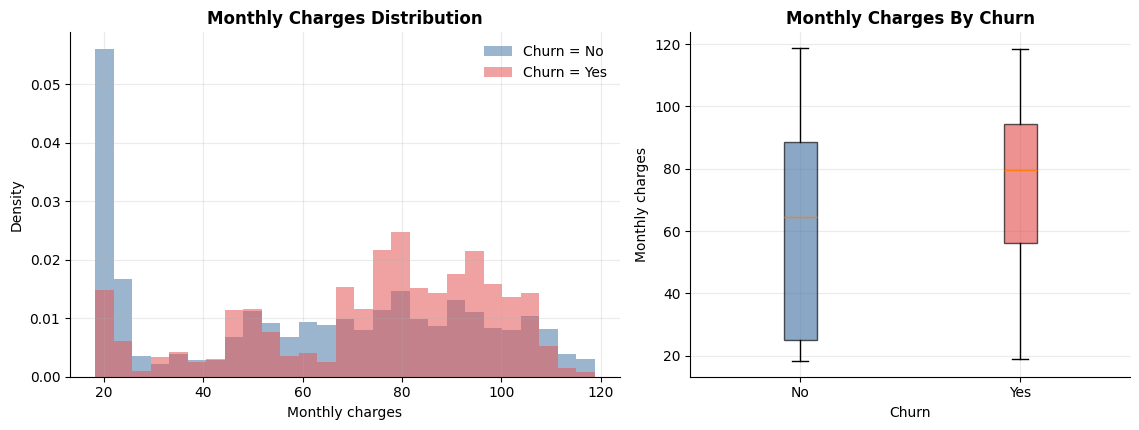

In [6]:
monthly_summary = (
    df.groupby("churn")["monthly_charges"]
    .agg(customers="count", mean="mean", median="median", min="min", max="max")
    .round(2)
)
display(monthly_summary)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"width_ratios": [1.25, 1]})

bins = np.linspace(df["monthly_charges"].min(), df["monthly_charges"].max(), 28)
for churn_value in ["No", "Yes"]:
    subset = df.loc[df["churn"].eq(churn_value), "monthly_charges"]
    axes[0].hist(subset, bins=bins, density=True, alpha=0.55, label=f"Churn = {churn_value}", color=CHURN_COLORS[churn_value])
axes[0].set_title("Monthly Charges Distribution")
axes[0].set_xlabel("Monthly charges")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

box_data = [df.loc[df["churn"].eq("No"), "monthly_charges"], df.loc[df["churn"].eq("Yes"), "monthly_charges"]]
box = axes[1].boxplot(box_data, tick_labels=["No", "Yes"], patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], [CHURN_COLORS["No"], CHURN_COLORS["Yes"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
axes[1].set_title("Monthly Charges By Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly charges")

fig.tight_layout()
path = save_figure(fig, "monthly_charges_distribution_by_churn.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()


**Conclusion:** Churned customers have higher monthly charges on average (**$74.44** mean, **$79.65** median) than retained customers (**$61.31** mean, **$64.45** median). This is an association, not evidence that higher charges cause churn; plan mix, contract type, and internet-service composition may be confounding factors.


## Churn By Payment Method

Question answered: Which payment methods are highest risk?

Payment method is useful for business review because it may point to billing friction, autopay adoption, or customer behavior differences.


,payment_method,customers,churned,churn_rate,churn_rate_pct
0,Electronic check,2365,1071,0.453,45.285
1,Mailed check,1604,308,0.192,19.202
2,Bank transfer (automatic),1542,258,0.167,16.732
3,Credit card (automatic),1521,232,0.153,15.253


Saved: reports\figures\churn_rate_by_payment_method.png


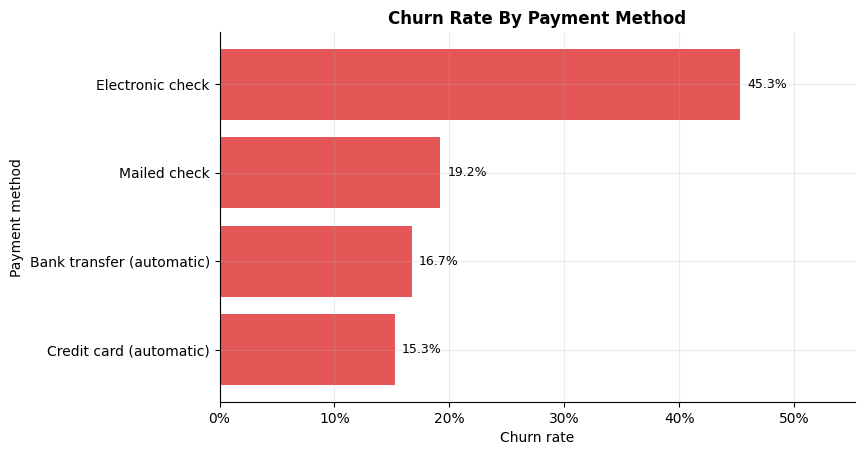

In [7]:
payment_summary = churn_rate_table(df, "payment_method", sort_by_rate=True)
display(payment_summary)

plot_data = payment_summary.sort_values("churn_rate")
fig, ax = plt.subplots(figsize=(8.2, 4.8))
bars = ax.barh(plot_data["payment_method"], plot_data["churn_rate"], color=RISK_COLOR)
ax.set_title("Churn Rate By Payment Method")
ax.set_xlabel("Churn rate")
ax.set_ylabel("Payment method")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, max(plot_data["churn_rate"]) + 0.10)
add_horizontal_labels(ax, plot_data["churn_rate"])

path = save_figure(fig, "churn_rate_by_payment_method.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()

**Conclusion:** Electronic check customers have the highest churn at **45.3%**. This segment includes **2,365 customers** and **1,071 churned customers**. Credit card autopay customers churn at **15.3%**.


## Churn By Internet Service

Question answered: How does churn differ by internet service type?

Internet service type can represent customer need, product tier, service experience, and price exposure. Segmenting churn by this field helps identify product areas that deserve deeper diagnostic analysis.

,internet_service,customers,churned,churn_rate,churn_rate_pct
0,Fiber optic,3096,1297,0.419,41.893
1,DSL,2416,459,0.190,18.998
2,No,1520,113,0.074,7.434


Saved: reports\figures\churn_rate_by_internet_service.png


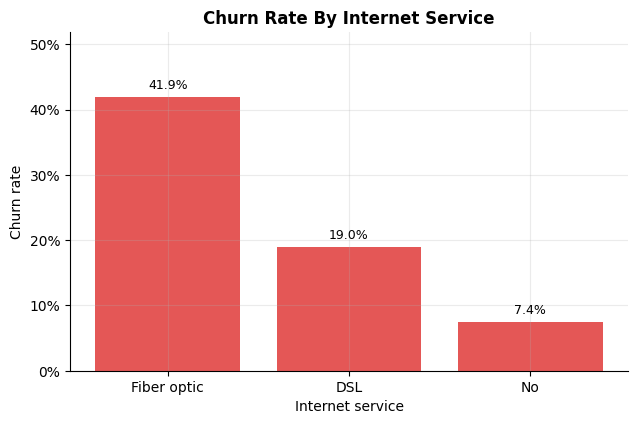

In [8]:
internet_summary = churn_rate_table(df, "internet_service", sort_by_rate=True)
display(internet_summary)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
bars = ax.bar(internet_summary["internet_service"], internet_summary["churn_rate"], color=RISK_COLOR)
ax.set_title("Churn Rate By Internet Service")
ax.set_xlabel("Internet service")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, max(internet_summary["churn_rate"]) + 0.10)
add_vertical_labels(ax, internet_summary["churn_rate"])

path = save_figure(fig, "churn_rate_by_internet_service.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()

**Conclusion:** Fiber optic customers churn at **41.9%**, compared with DSL at **19.0%** and no internet service at **7.4%**. Fiber optic is also a large segment with **3,096 customers** and **1,297 churned customers**.


## Churn By Selected Service Flags

Question answered: Which service-related features are most associated with churn?

These service flags only make business sense for customers who have internet service. Customers with no internet service cannot buy these add-ons, so this analysis filters to `internet_service != "No"` before comparing churn rates.


,service_flag,has_service_label,customers,churned,churn_rate,churn_rate_pct
0,Online security,No,3497,1461,0.418,41.779
1,Online security,Yes,2015,295,0.146,14.640
2,Tech support,No,3472,1446,0.416,41.647
3,Tech support,Yes,2040,310,0.152,15.196
4,Streaming TV,No,2809,942,0.335,33.535
5,Streaming TV,Yes,2703,814,0.301,30.115
6,Streaming movies,No,2781,938,0.337,33.729
7,Streaming movies,Yes,2731,818,0.300,29.952


has_service_label,service_flag,churn_without_service,churn_with_service,absolute_gap_pct_points
0,Online security,0.418,0.146,27.138
3,Tech support,0.416,0.152,26.451
2,Streaming movies,0.337,0.300,3.776
1,Streaming TV,0.335,0.301,3.420


Saved: reports\figures\churn_rate_by_service_flags.png


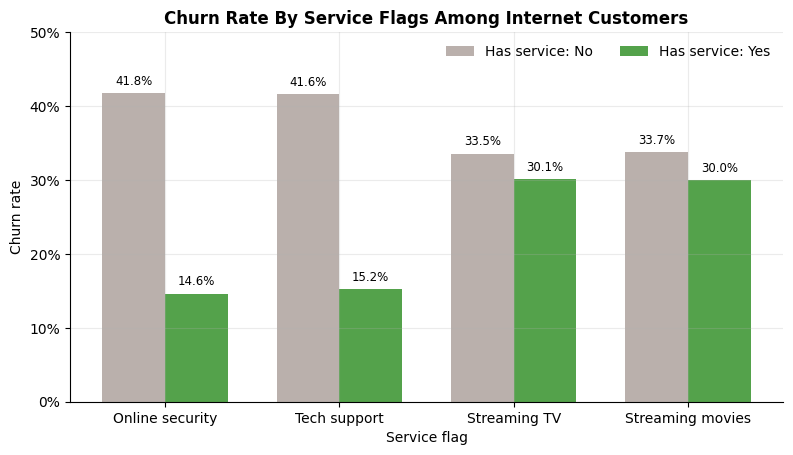

In [9]:
internet_customers = df[df["internet_service"] != "No"].copy()
service_flags = ["has_online_security", "has_tech_support", "has_streaming_tv", "has_streaming_movies"]
service_labels = {
    "has_online_security": "Online security",
    "has_tech_support": "Tech support",
    "has_streaming_tv": "Streaming TV",
    "has_streaming_movies": "Streaming movies",
}

service_long = []
for flag in service_flags:
    summary = churn_rate_table(internet_customers, flag).rename(columns={flag: "has_service"})
    summary["service_flag"] = service_labels[flag]
    service_long.append(summary)

service_summary = pd.concat(service_long, ignore_index=True)
service_summary["has_service_label"] = service_summary["has_service"].map({0: "No", 1: "Yes"})
service_summary = service_summary[["service_flag", "has_service_label", "customers", "churned", "churn_rate", "churn_rate_pct"]]
display(service_summary)

service_gap = (
    service_summary.pivot(index="service_flag", columns="has_service_label", values="churn_rate")
    .rename(columns={"No": "churn_without_service", "Yes": "churn_with_service"})
    .reset_index()
)
service_gap["absolute_gap_pct_points"] = (service_gap["churn_with_service"] - service_gap["churn_without_service"]).abs() * 100
display(service_gap.sort_values("absolute_gap_pct_points", ascending=False))

ordered_labels = [service_labels[flag] for flag in service_flags]
x = np.arange(len(ordered_labels))
width = 0.36
fig, ax = plt.subplots(figsize=(9.2, 4.8))

for offset, label, color in [(-width / 2, "No", NEUTRAL_COLOR), (width / 2, "Yes", SUPPORT_COLOR)]:
    rates = []
    for service in ordered_labels:
        row = service_summary.loc[
            service_summary["service_flag"].eq(service) & service_summary["has_service_label"].eq(label)
        ]
        rates.append(row["churn_rate"].iloc[0])
    bars = ax.bar(x + offset, rates, width=width, label=f"Has service: {label}", color=color)
    for patch, value in zip(bars, rates):
        ax.annotate(
            f"{value:.1%}",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=8.5,
        )

ax.set_title("Churn Rate By Service Flags Among Internet Customers")
ax.set_xlabel("Service flag")
ax.set_ylabel("Churn rate")
ax.set_xticks(x)
ax.set_xticklabels(ordered_labels)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.50)
ax.legend(frameon=False, ncols=2)

path = save_figure(fig, "churn_rate_by_service_flags.png")
print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
plt.show()


**Conclusion:** Among internet customers, churn is much higher for customers without online security (**41.8%**) than with online security (**14.6%**), and higher without tech support (**41.6%**) than with tech support (**15.2%**). This is association only, not causality; these service flags may proxy for bundle maturity, customer engagement, or customer type. Streaming TV and streaming movies show smaller differences among internet customers, so they are weaker churn-risk signals than security and support.


## Business Priority View

The strongest descriptive EDA segments are not only high-rate segments; they also need enough customers and churned customers to be operationally useful. This table summarizes the most important candidate churn-driver segments from the earlier charts.


In [10]:
priority_rows = [
    ("tenure_group = 0-11 months", tenure_summary, "tenure_group", "0-11 months"),
    ("Electronic check", payment_summary, "payment_method", "Electronic check"),
    ("Month-to-month contract", contract_summary, "contract", "Month-to-month"),
    ("Fiber optic internet", internet_summary, "internet_service", "Fiber optic"),
]

rows = []
for segment, table, column, value in priority_rows:
    row = table.loc[table[column].eq(value)].iloc[0]
    rows.append({"segment": segment, "customers": row["customers"], "churned": row["churned"], "churn_rate_pct": row["churn_rate_pct"]})

for service_name in ["Online security", "Tech support"]:
    row = service_summary[
        service_summary["service_flag"].eq(service_name) & service_summary["has_service_label"].eq("No")
    ].iloc[0]
    rows.append({
        "segment": f"Internet customers without {service_name.lower()}",
        "customers": row["customers"],
        "churned": row["churned"],
        "churn_rate_pct": row["churn_rate_pct"],
    })

priority_summary = pd.DataFrame(rows)
priority_summary["churn_share_pct"] = priority_summary["churned"] / df["churn_flag"].sum() * 100
priority_summary["lift_vs_baseline"] = priority_summary["churn_rate_pct"] / (df["churn_flag"].mean() * 100)
priority_summary = priority_summary.sort_values(["churn_rate_pct", "churned"], ascending=False).reset_index(drop=True)

display(priority_summary.round({"churn_rate_pct": 1, "churn_share_pct": 1, "lift_vs_baseline": 2}))


,segment,customers,churned,churn_rate_pct,churn_share_pct,lift_vs_baseline
0,tenure_group = 0-11 months,2058,999,48.500,53.500,1.830
1,Electronic check,2365,1071,45.300,57.300,1.700
2,Month-to-month contract,3875,1655,42.700,88.600,1.610
3,Fiber optic internet,3096,1297,41.900,69.400,1.580
4,Internet customers without online security,3497,1461,41.800,78.200,1.570
5,Internet customers without tech support,3472,1446,41.600,77.400,1.570


**Conclusion:** The highest-priority descriptive segments combine high churn rates with large churn volume. Customers in the `0-11 months` tenure group, electronic-check customers, month-to-month customers, and fiber optic customers are especially important because each segment has above-baseline churn and substantial customer count.


## EDA Takeaways

- The overall churn baseline is high enough to justify targeted retention work.
- Month-to-month contracts and the `0-11 months` tenure group are the clearest lifecycle risk signals.
- Electronic check customers stand out as a high-risk billing segment.
- Fiber optic customers have elevated churn and should be reviewed with price and support context.
- Churned customers have higher monthly charges, but this may reflect plan mix, contract type, or internet-service composition rather than price alone.
- Among internet customers, lack of online security and lack of tech support are associated with higher churn, but these flags may proxy for bundle maturity, engagement, or customer type.
- Streaming add-ons are not a major churn-risk signal after filtering to internet customers.

These are descriptive EDA findings only. Later steps can validate which patterns remain important after controlling for overlapping customer attributes.
